# Credit Card Fraud Detection
Exploratory Data Analysis (EDA) and Preprocessing pipeline for credit card fraud classification.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.feature_selection import mutual_info_classif

# General display and plotting preferences
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 1000)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Data Ingestion & Initial Inspection

In [3]:
# Download dataset if not already present locally
if not os.path.exists("creditcard.csv"):
    os.system("git clone --depth 1 https://github.com/garvittsingla/creditCardFraudDetectionSystem.git ccdata")
    os.system("mv ccdata/creditcard.csv . && rm -rf ccdata")

df = pd.read_csv("creditcard.csv")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [5]:
# Overview of class distribution and key columns
fraud_count = df["Class"].sum()
fraud_rate = df["Class"].mean() * 100

print(f"Time span: {df["Time"].max() / 3600:.1f} hours ({df["Time"].max():,.0f} seconds)")
print(f"Amount range: €{df["Amount"].min():.2f} to €{df["Amount"].max():,.2f}")
print(f"Amount mean: €{df["Amount"].mean():.2f} | median: €{df["Amount"].median():.2f}")
print(f"Class distribution:\n{df["Class"].value_counts()}")
print(f"\nFraud rate: {fraud_rate:.4f}%")
print(f"Imbalance ratio: {len(df[df["Class"] == 0]) / fraud_count:.1f} : 1")

Time span: 48.0 hours (172,792 seconds)
Amount range: €0.00 to €25,691.16
Amount mean: €88.35 | median: €22.00
Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud rate: 0.1727%
Imbalance ratio: 577.9 : 1


## 2. Data Cleaning & Integrity Checks

In [6]:
# Check for duplicate rows
duplicates = df.duplicated().sum()
fraud_duplicates = df[df.duplicated()]["Class"].sum()
print(f"Duplicate rows: {duplicates:,} ({fraud_duplicates} fraudulent)")

# Inspect sample duplicates before removal
df[df.duplicated(keep=False)].sort_values(by=list(df.columns[:3])).head(4)

Duplicate rows: 1,081 (19 fraudulent)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
34,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,-0.482474,0.87180,0.853447,-0.571822,0.102252,-1.519991,-0.285912,-0.309633,-0.403902,-0.823743,-0.283264,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0
35,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,-0.482474,0.87180,0.853447,-0.571822,0.102252,-1.519991,-0.285912,-0.309633,-0.403902,-0.823743,-0.283264,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0
32,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,-0.484688,0.87249,0.851636,-0.571745,0.100974,-1.519772,-0.284376,-0.310524,-0.404248,-0.823374,-0.290348,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0
33,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,-0.484688,0.87249,0.851636,-0.571745,0.100974,-1.519772,-0.284376,-0.310524,-0.404248,-0.823374,-0.290348,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0


In [7]:
# Remove duplicates and reindex
initial_len = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Dropped {initial_len - len(df):,} duplicate rows. Remaining rows: {len(df):,} (Frauds: {df["Class"].sum()})")

Dropped 1,081 duplicate rows. Remaining rows: 283,726 (Frauds: 473)


In [8]:
# Integrity and boundary checks
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Negative amounts: {(df["Amount"] < 0).sum()}")
print(f"Negative timestamps: {(df["Time"] < 0).sum()}")
print(f"Non-binary class labels: {(~df["Class"].isin([0, 1])).sum()}")
print(f"Constant columns: {[c for c in df.columns if df[c].nunique() == 1]}")
print(f"Non-numeric columns: {list(df.select_dtypes(exclude=np.number).columns)}")

Missing values: 0
Negative amounts: 0
Negative timestamps: 0
Non-binary class labels: 0
Constant columns: []
Non-numeric columns: []


In [9]:
# Zero-amount transactions
zero_amt = df[df["Amount"] == 0]
print(f"Zero-amount transactions: {len(zero_amt)} ({len(zero_amt) / len(df):.2%})")
print(f"Frauds among zero-amount: {zero_amt["Class"].sum()} (Fraud rate: {zero_amt["Class"].mean():.2%})")

# Outlier check on Amount using IQR
q25, q75 = df["Amount"].quantile([0.25, 0.75])
iqr = q75 - q25
upper_fence = q75 + 1.5 * iqr
outliers = df[df["Amount"] > upper_fence]
print(f"\nIQR upper fence: €{upper_fence:.2f}")
print(f"Transactions above upper fence: {len(outliers):,} ({len(outliers) / len(df):.2%})")
print(f"Frauds in upper fence outliers: {outliers["Class"].sum()}")
print("-> Retaining all outliers; extreme transaction amounts carry important fraud signals.")

Zero-amount transactions: 1808 (0.64%)
Frauds among zero-amount: 25 (Fraud rate: 1.38%)

IQR upper fence: €185.38
Transactions above upper fence: 31,685 (11.17%)
Frauds in upper fence outliers: 87
-> Retaining all outliers; extreme transaction amounts carry important fraud signals.


## 3. Feature Engineering
We derive temporal indicators from `Time` (seconds elapsed) and handle the extreme right-skew of `Amount`:
- `HOUR`: Hour of the day (0-23)
- `IS_NIGHT`: Indicator for early morning transactions (00:00-05:59)
- `TIME_PERIOD`: Categorical bins (Night, Morning, Afternoon, Evening)
- `LOG_AMOUNT`: `log1p(Amount)` transformation to normalize amount values and handle €0 cleanly
- `AMOUNT_BUCKET`: Binned transaction size tiers

In [10]:
# Time-of-day features
df["HOUR"] = ((df["Time"] // 3600) % 24).astype(int)
df["IS_NIGHT"] = df["HOUR"].between(0, 5).astype(int)

# Log transform amount
df["LOG_AMOUNT"] = np.log1p(df["Amount"])

# Discretize time periods and transaction amount tiers
df["TIME_PERIOD"] = pd.cut(
    df["HOUR"],
    bins=[-1, 5, 11, 17, 23],
    labels=["Night", "Morning", "Afternoon", "Evening"]
)

df["AMOUNT_BUCKET"] = pd.cut(
    df["Amount"],
    bins=[-0.01, 10, 50, 200, 1000, 30000],
    labels=["0-10", "10-50", "50-200", "200-1000", "1000+"]
)

df[["Time", "HOUR", "TIME_PERIOD", "IS_NIGHT", "Amount", "LOG_AMOUNT", "AMOUNT_BUCKET"]].head()

,Time,HOUR,TIME_PERIOD,IS_NIGHT,Amount,LOG_AMOUNT,AMOUNT_BUCKET
0,0.0,0,Night,1,149.62,5.014760,50-200
1,0.0,0,Night,1,2.69,1.305626,0-10
2,1.0,0,Night,1,378.66,5.939276,200-1000
3,1.0,0,Night,1,123.50,4.824306,50-200
4,2.0,0,Night,1,69.99,4.262539,50-200


In [11]:
# Validate engineered features
new_features = ["HOUR", "IS_NIGHT", "LOG_AMOUNT"]
print(f"NaNs introduced: {df[new_features].isna().sum().sum()}")
print(f"Infinities introduced: {np.isinf(df[new_features].values).sum()}")

print("\nTransactions by Time Period:")
print(df["TIME_PERIOD"].value_counts())

print("\nTransactions by Amount Tier:")
print(df["AMOUNT_BUCKET"].value_counts().sort_index())

NaNs introduced: 0
Infinities introduced: 0

Transactions by Time Period:
TIME_PERIOD
Afternoon    96121
Evening      93120
Morning      70643
Night        23842
Name: count, dtype: int64

Transactions by Amount Tier:
AMOUNT_BUCKET
0-10        99821
10-50       90327
50-200      64808
200-1000    25835
1000+        2935
Name: count, dtype: int64


In [12]:
# Compare fraud rates across engineered segments
night_rate = df[df["IS_NIGHT"] == 1]["Class"].mean() * 100
day_rate = df[df["IS_NIGHT"] == 0]["Class"].mean() * 100

print(f"Fraud rate at night (00-05h): {night_rate:.3f}%")
print(f"Fraud rate during day (06-23h): {day_rate:.3f}%")
print(f"Night transactions are {night_rate / day_rate:.1f}x riskier.")

print("\nFraud rate by amount bucket (%):")
print((df.groupby("AMOUNT_BUCKET", observed=True)["Class"].mean() * 100).round(3))

Fraud rate at night (00-05h): 0.482%
Fraud rate during day (06-23h): 0.138%
Night transactions are 3.5x riskier.

Fraud rate by amount bucket (%):
AMOUNT_BUCKET
0-10        0.238
10-50       0.061
50-200      0.151
200-1000    0.283
1000+       0.307
Name: Class, dtype: float64


In [13]:
# Encode categorical features
# Ordinal encoding for amount tiers
df["AMOUNT_BUCKET_ENC"] = df["AMOUNT_BUCKET"].cat.codes

# One-hot encode nominal time periods
tp_dummies = pd.get_dummies(df["TIME_PERIOD"], prefix="TP", drop_first=True, dtype=int)
df = pd.concat([df, tp_dummies], axis=1)

df[["TIME_PERIOD", "AMOUNT_BUCKET", "AMOUNT_BUCKET_ENC"] + list(tp_dummies.columns)].drop_duplicates()

,TIME_PERIOD,AMOUNT_BUCKET,AMOUNT_BUCKET_ENC,TP_Morning,TP_Afternoon,TP_Evening
0,Night,50-200,2,0,0,0
1,Night,0-10,0,0,0,0
2,Night,200-1000,3,0,0,0
7,Night,10-50,1,0,0,0
49,Night,1000+,4,0,0,0
12296,Morning,0-10,0,1,0,0
12297,Morning,10-50,1,1,0,0
12301,Morning,50-200,2,1,0,0
12403,Morning,200-1000,3,1,0,0
12500,Morning,1000+,4,1,0,0


## 4. Exploratory Data Analysis (EDA)

/tmp/ipykernel_616/2480212009.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=["Genuine (0)", "Fraud (1)"], y=counts.values, palette=["#3274a1", "#e15759"], ax=ax)


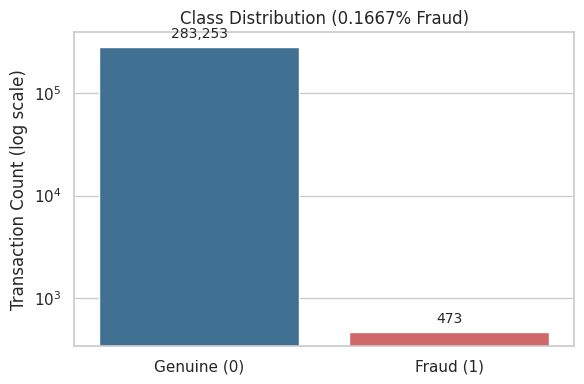

Genuine: 283,253 | Fraud: 473 | Imbalance: 598.8 : 1


In [14]:
# Target Class Distribution
counts = df["Class"].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=["Genuine (0)", "Fraud (1)"], y=counts.values, palette=["#3274a1", "#e15759"], ax=ax)
ax.set_yscale("log")
ax.set_ylabel("Transaction Count (log scale)")
ax.set_title(f"Class Distribution ({df["Class"].mean():.4%} Fraud)")

for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha="center", va="bottom", xytext=(0, 4), textcoords="offset points", fontsize=10)

plt.tight_layout()
plt.show()

print(f"Genuine: {counts[0]:,} | Fraud: {counts[1]:,} | Imbalance: {counts[0] / counts[1]:.1f} : 1")

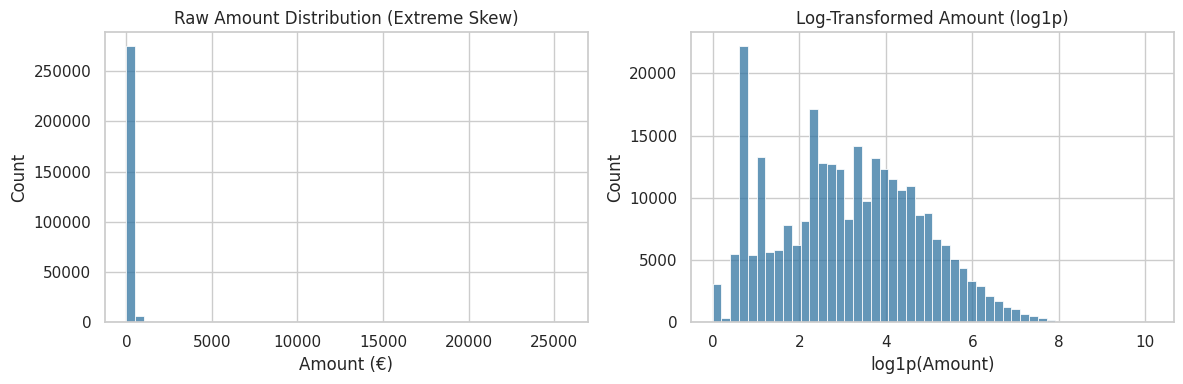

Skewness — Raw Amount: 16.98 | log1p(Amount): 0.16
Amount summary — Mean: €88.47, Median: €22.00, Max: €25,691.16


In [15]:
# Raw vs Log-transformed Amount Distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["Amount"], bins=50, color="#3274a1", ax=axes[0])
axes[0].set_title("Raw Amount Distribution (Extreme Skew)")
axes[0].set_xlabel("Amount (€)")

sns.histplot(df["LOG_AMOUNT"], bins=50, color="#3274a1", ax=axes[1])
axes[1].set_title("Log-Transformed Amount (log1p)")
axes[1].set_xlabel("log1p(Amount)")

plt.tight_layout()
plt.show()

print(f"Skewness — Raw Amount: {df["Amount"].skew():.2f} | log1p(Amount): {df["LOG_AMOUNT"].skew():.2f}")
print(f"Amount summary — Mean: €{df["Amount"].mean():.2f}, Median: €{df["Amount"].median():.2f}, Max: €{df["Amount"].max():,.2f}")

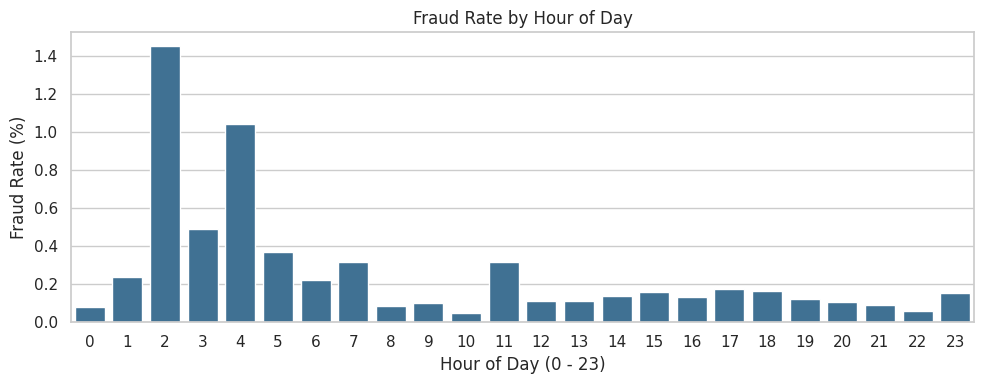

Peak fraud hour: 02:00 (1.451%)
Lowest fraud hour: 10:00 (0.048%)


In [16]:
# Fraud Rate by Hour of Day
hourly = df.groupby("HOUR")["Class"].mean().mul(100)

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(x=hourly.index, y=hourly.values, color="#3274a1", ax=ax)
ax.set_title("Fraud Rate by Hour of Day")
ax.set_xlabel("Hour of Day (0 - 23)")
ax.set_ylabel("Fraud Rate (%)")
plt.tight_layout()
plt.show()

print(f"Peak fraud hour: {hourly.idxmax():02d}:00 ({hourly.max():.3f}%)")
print(f"Lowest fraud hour: {hourly.idxmin():02d}:00 ({hourly.min():.3f}%)")

/tmp/ipykernel_616/557199197.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Class", y="LOG_AMOUNT", data=df, palette=["#3274a1", "#e15759"], showfliers=False, ax=axes[0])


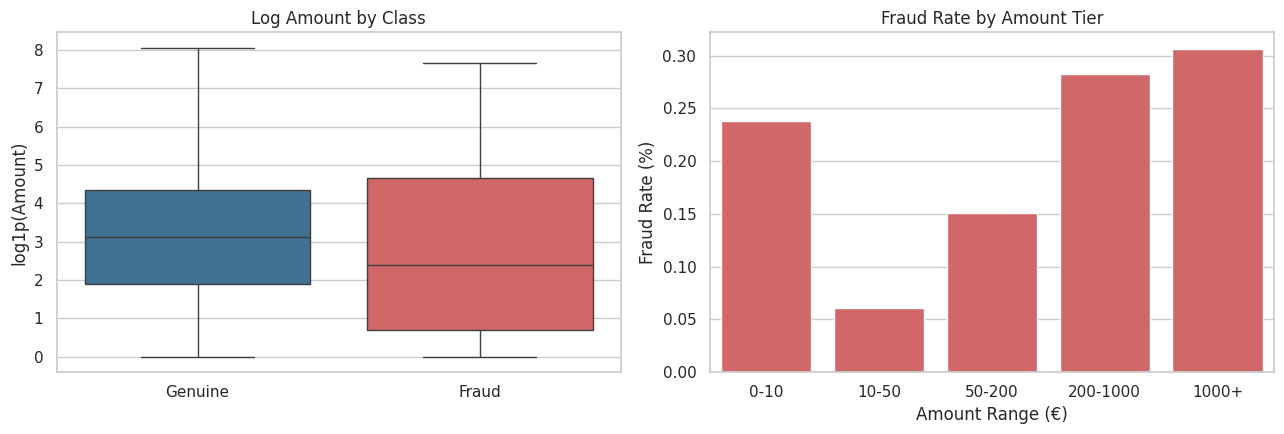

        count    mean  median       max
Class                                  
0      283253   88.41   22.00  25691.16
1         473  123.87    9.82   2125.87


In [17]:
# Amount Distribution & Fraud Rate by Size Tier
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))


sns.boxplot(x="Class", y="LOG_AMOUNT", data=df, palette=["#3274a1", "#e15759"], showfliers=False, ax=axes[0])
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["Genuine", "Fraud"])
axes[0].set_title("Log Amount by Class")
axes[0].set_xlabel("")
axes[0].set_ylabel("log1p(Amount)")

bucket_rates = df.groupby("AMOUNT_BUCKET", observed=True)["Class"].mean().mul(100)
sns.barplot(x=bucket_rates.index.astype(str), y=bucket_rates.values, color="#e15759", ax=axes[1])
axes[1].set_title("Fraud Rate by Amount Tier")
axes[1].set_xlabel("Amount Range (€)")
axes[1].set_ylabel("Fraud Rate (%)")

plt.tight_layout()
plt.show()

print(df.groupby("Class")["Amount"].agg(["count", "mean", "median", "max"]).round(2))

Top 10 features correlating with Class:
V17   -0.313
V14   -0.293
V12   -0.251
V10   -0.207
V16   -0.187
V3    -0.182
V7    -0.172
V11    0.149
V4     0.129
V18   -0.105
Name: Class, dtype: float64


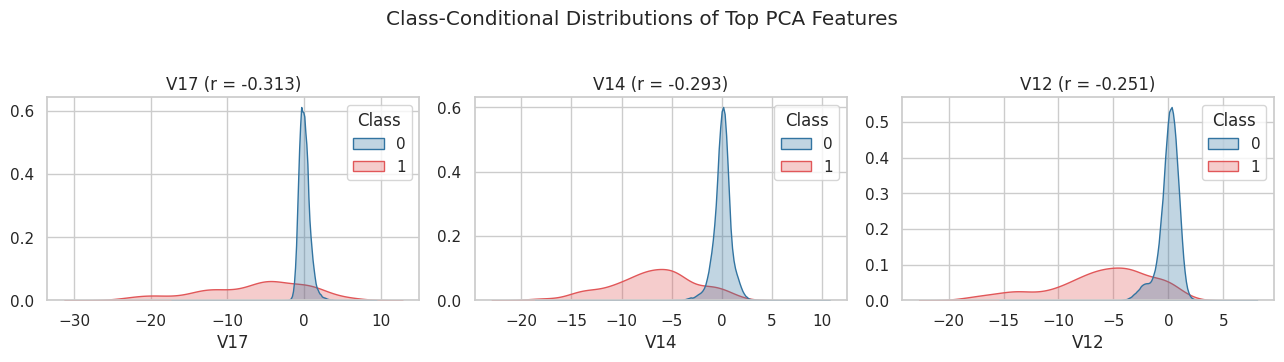

In [18]:
# Correlation of PCA Features with Class & KDE Plots
corr_target = (
    df.drop(columns=["TIME_PERIOD", "AMOUNT_BUCKET"])
      .corr(numeric_only=True)["Class"]
      .drop("Class")
      .sort_values(key=abs, ascending=False)
)

print("Top 10 features correlating with Class:")
print(corr_target.head(10).round(3))

top3 = ["V17", "V14", "V12"]
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))

for ax, feat in zip(axes, top3):
    sns.kdeplot(
        data=df, x=feat, hue="Class", palette=["#3274a1", "#e15759"],
        common_norm=False, fill=True, alpha=0.3, ax=ax
    )
    ax.set_title(f"{feat} (r = {corr_target[feat]:.3f})")
    ax.set_ylabel("")

plt.suptitle("Class-Conditional Distributions of Top PCA Features", y=1.03)
plt.tight_layout()
plt.show()

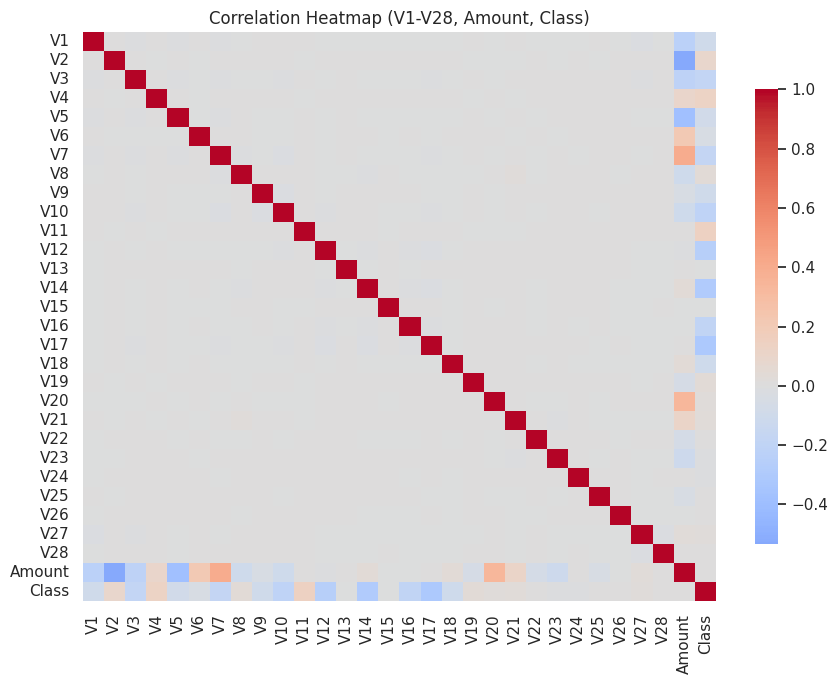

Largest pairwise |correlation| among V1-V28: 0.0189


In [19]:
# Correlation Heatmap
v_cols = [f"V{i}" for i in range(1, 29)]

plt.figure(figsize=(9, 7))
sns.heatmap(df[v_cols + ["Amount", "Class"]].corr(), cmap="coolwarm", center=0, cbar_kws={"shrink": 0.8})
plt.title("Correlation Heatmap (V1-V28, Amount, Class)")
plt.tight_layout()
plt.show()

max_pairwise_v = df[v_cols].corr().abs().values[np.triu_indices(28, 1)].max()
print(f"Largest pairwise |correlation| among V1-V28: {max_pairwise_v:.4f}")

## 5. Train / Test Split & Feature Scaling
We drop raw `Time`, `Amount`, and unencoded categorical columns, using only engineered and scaled features.
We use a stratified 80/20 train/test split to maintain identical fraud ratios.

In [20]:
# Prepare feature matrix X and target y
drop_cols = ["Time", "Amount", "TIME_PERIOD", "AMOUNT_BUCKET"]
model_df = df.drop(columns=drop_cols)

X = model_df.drop(columns=["Class"])
y = model_df["Class"]

print(f"X shape: {X.shape} | y shape: {y.shape}")
print(f"Features ({len(X.columns)}): {list(X.columns)}")

X shape: (283726, 35) | y shape: (283726,)
Features (35): ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'HOUR', 'IS_NIGHT', 'LOG_AMOUNT', 'AMOUNT_BUCKET_ENC', 'TP_Morning', 'TP_Afternoon', 'TP_Evening']


In [21]:
# Stratified train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f"Train set: {X_train.shape[0]:,} rows ({y_train.sum()} frauds, {y_train.mean():.4%})")
print(f"Test set : {X_test.shape[0]:,} rows ({y_test.sum()} frauds, {y_test.mean():.4%})")

Train set: 226,980 rows (378 frauds, 0.1665%)
Test set : 56,746 rows (95 frauds, 0.1674%)


In [22]:
# Scale non-PCA features (LOG_AMOUNT, HOUR)
# RobustScaler is less sensitive to remaining outliers compared to StandardScaler
to_scale = ["LOG_AMOUNT", "HOUR"]

scaler = RobustScaler()
scaler.fit(X_train[to_scale])

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[to_scale] = scaler.transform(X_train[to_scale])
X_test_scaled[to_scale] = scaler.transform(X_test[to_scale])

# Compare raw vs StandardScaler vs RobustScaler on LOG_AMOUNT
scaler_compare = pd.DataFrame({
    "Raw": X_train["LOG_AMOUNT"].describe(),
    "StandardScaler": pd.Series(StandardScaler().fit_transform(X_train[["LOG_AMOUNT"]]).ravel()).describe(),
    "RobustScaler": pd.Series(X_train_scaled["LOG_AMOUNT"]).describe()
}).round(3)
scaler_compare

,Raw,StandardScaler,RobustScaler
count,226980.000,226980.000,226980.000
mean,3.156,0.000,0.007
std,1.656,1.000,0.671
min,0.000,-1.906,-1.272
25%,1.901,-0.758,-0.502
50%,3.139,-0.010,0.000
75%,4.368,0.731,0.498
max,9.886,4.063,2.735


## 6. Feature Importance & Preprocessing Verification

/tmp/ipykernel_616/670129242.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mi_top.values, y=mi_top.index, palette="crest", ax=axes[0])
/tmp/ipykernel_616/670129242.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_top.values, y=corr_top.index, palette="vlag", ax=axes[1])


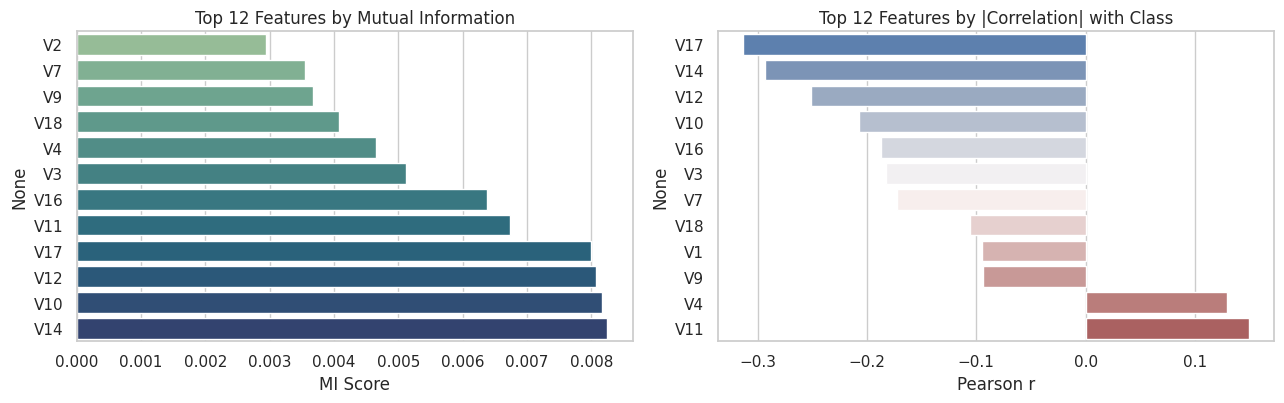

Top 10 features by Mutual Information:
V14    0.00823
V10    0.00816
V12    0.00807
V17    0.00799
V11    0.00673
V16    0.00638
V3     0.00512
V4     0.00466
V18    0.00407
V9     0.00368
dtype: float64


In [23]:
# Compute Mutual Information on a representative sample for speed
sample_idx = X_train_scaled.sample(40000, random_state=RANDOM_STATE).index

mi_scores = mutual_info_classif(
    X_train_scaled.loc[sample_idx],
    y_train.loc[sample_idx],
    random_state=RANDOM_STATE
)
mi = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

mi_top = mi.head(12).sort_values()
sns.barplot(x=mi_top.values, y=mi_top.index, palette="crest", ax=axes[0])
axes[0].set_title("Top 12 Features by Mutual Information")
axes[0].set_xlabel("MI Score")

corr_top = corr_target.head(12).sort_values()
sns.barplot(x=corr_top.values, y=corr_top.index, palette="vlag", ax=axes[1])
axes[1].set_title("Top 12 Features by |Correlation| with Class")
axes[1].set_xlabel("Pearson r")

plt.tight_layout()
plt.show()

print("Top 10 features by Mutual Information:")
print(mi.head(10).round(5))

In [24]:
# Final validation check
print("Preprocessed Dataset Verification:")
print(f"  Rows (cleaned)        : {len(df):,}")
print(f"  Feature count (X)     : {X_train_scaled.shape[1]}")
print(f"  X_train shape         : {X_train_scaled.shape} (Frauds: {y_train.sum()})")
print(f"  X_test shape          : {X_test_scaled.shape} (Frauds: {y_test.sum()})")
print(f"  Null values in train  : {X_train_scaled.isna().sum().sum()}")
print(f"  Null values in test   : {X_test_scaled.isna().sum().sum()}")
print(f"  Infinities in train   : {np.isinf(X_train_scaled.values).sum()}")
print(f"  Non-numeric columns   : {list(X_train_scaled.select_dtypes(exclude=np.number).columns) or None}")
print(f"  Train fraud rate      : {y_train.mean():.4%}")
print(f"  Test fraud rate       : {y_test.mean():.4%}")

Preprocessed Dataset Verification:
  Rows (cleaned)        : 283,726
  Feature count (X)     : 35
  X_train shape         : (226980, 35) (Frauds: 378)
  X_test shape          : (56746, 35) (Frauds: 95)
  Null values in train  : 0
  Null values in test   : 0
  Infinities in train   : 0
  Non-numeric columns   : None
  Train fraud rate      : 0.1665%
  Test fraud rate       : 0.1674%


In [25]:
# Preview processed sample features
X_train_scaled[["V14", "V17", "V12", "V10", "V4", "LOG_AMOUNT", "HOUR", "IS_NIGHT", "AMOUNT_BUCKET_ENC", "TP_Morning", "TP_Evening"]].head()

,V14,V17,V12,V10,V4,LOG_AMOUNT,HOUR,IS_NIGHT,AMOUNT_BUCKET_ENC,TP_Morning,TP_Evening
225399,-0.313460,0.381516,-0.705588,1.567867,-2.577803,0.144933,0.111111,0,1,0,0
133746,0.862657,-0.265345,1.762389,-0.482635,-0.038359,-0.429998,0.777778,0,0,0,1
185792,-0.689465,0.793328,1.039161,-0.497766,0.129310,-0.149784,-0.444444,0,1,1,0
148925,1.239627,-0.475182,-1.775051,1.146705,3.880231,-0.094070,-1.555556,1,1,0,0
18398,-0.044638,0.787525,0.014396,1.492821,-1.547659,0.032392,-0.777778,0,1,1,0


In [26]:
# Preview target
y_train.head().to_frame("Class")

,Class
225399,0
133746,0
185792,0
148925,0
18398,0
